In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
X = np.array([1, 3, 4, 6, 7])
y = np.array([15, 35, 45, 65, 75])

<Axes: >

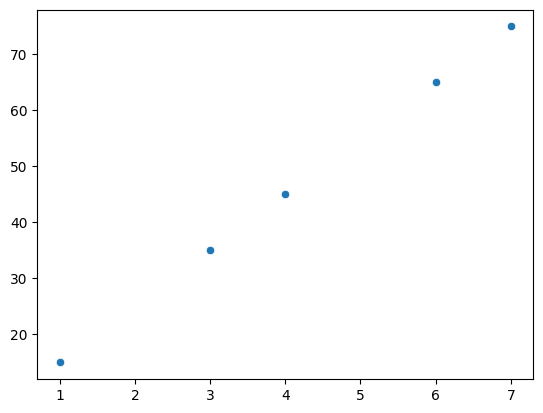

In [3]:
sns.scatterplot(x=X, y=y)

In [4]:
def make_pred(X,y,w,b):
    m=X.shape[0]

    pred_list = np.zeros((m,))

    for i in range(m):
        pred_list[i] = w * X[i] + b

    return pred_list

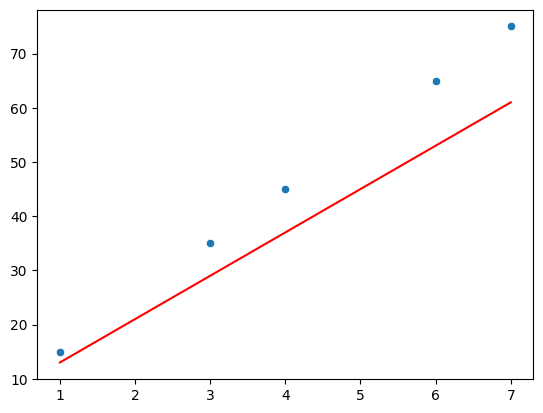

In [5]:
prediction = make_pred(X,y,8,5)
prediction

sns.scatterplot(x=X, y=y)
plt.plot(X, prediction, color='red')

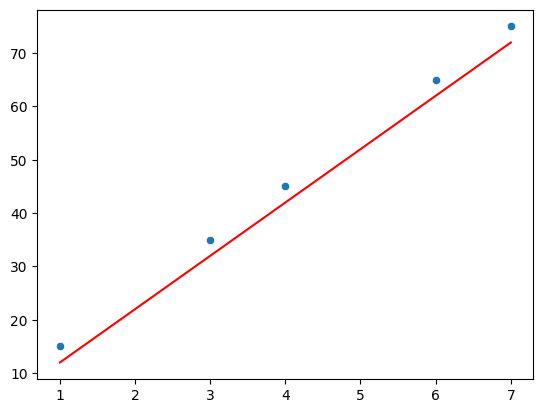

In [6]:
prediction = make_pred(X,y,10,2)
prediction

sns.scatterplot(x=X, y=y)
plt.plot(X, prediction, color='red')

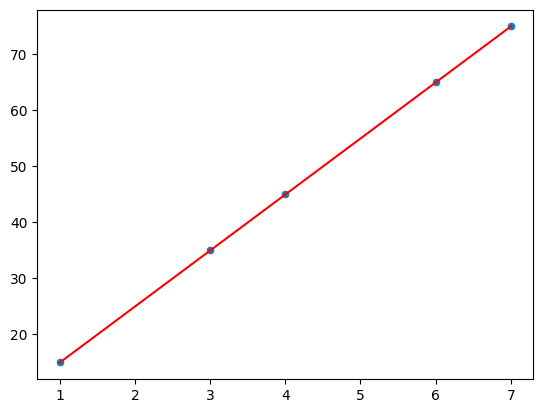

In [7]:
prediction = make_pred(X,y,10,5)
prediction

sns.scatterplot(x=X, y=y)
plt.plot(X, prediction, color='red')

In [8]:
def compute_cost(X,y,w,b):
    m=X.shape[0] # no of data points

    cost =0.0
    pred_list = np.zeros((m,))

    for i in range(m):
        prediction = w * X[i] + b
        error = prediction - y[i]
        error_squared = error ** 2
        cost = cost+ error_squared

    cost = cost / (2*m)

    return cost


[ 6. 16. 21. 31. 36.]


Text(0.5, 1.0, 'cost: 369.5, for w=5, b=1')

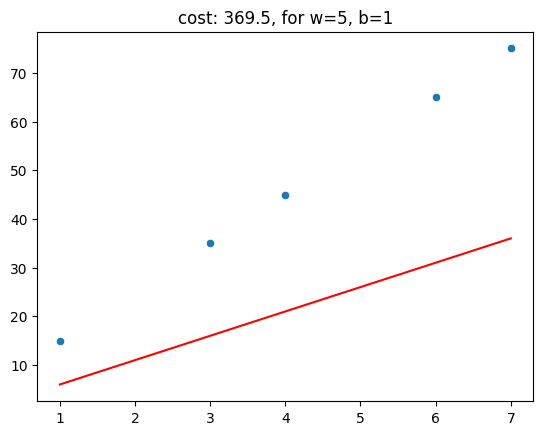

In [9]:
w=5
b=1

prediction = make_pred(X,y,w=w,b=b)
print(prediction)

sns.scatterplot(x=X, y=y)
plt.plot(X, prediction, color='red')
plt.title(f"cost: {compute_cost(X,y,w=w,b=b)}, for w={w}, b={b}")

[10. 26. 34. 50. 58.]


Text(0.5, 1.0, 'cost: 74.1, for w=8, b=2')

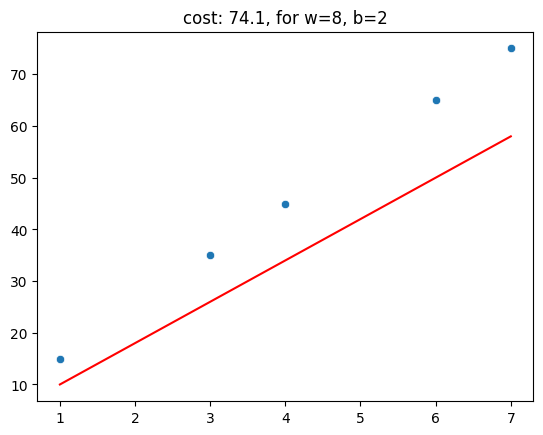

In [10]:
w=8
b=2

prediction = make_pred(X,y,w=w,b=b)
print(prediction)

sns.scatterplot(x=X, y=y)
plt.plot(X, prediction, color='red')
plt.title(f"cost: {compute_cost(X,y,w=w,b=b)}, for w={w}, b={b}")

[13. 33. 43. 63. 73.]


Text(0.5, 1.0, 'cost: 2.0, for w=10, b=3')

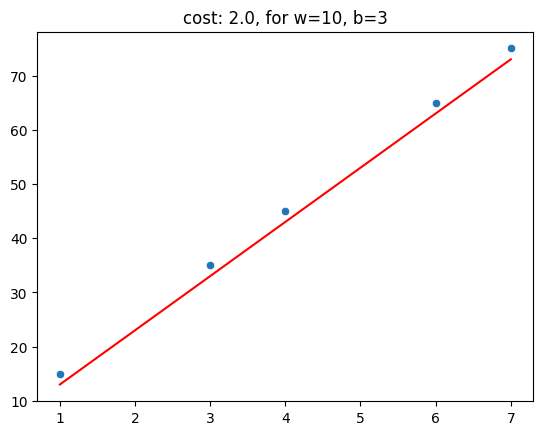

In [11]:
w=10
b=3

prediction = make_pred(X,y,w=w,b=b)
print(prediction)

sns.scatterplot(x=X, y=y)
plt.plot(X, prediction, color='red')
plt.title(f"cost: {compute_cost(X,y,w=w,b=b)}, for w={w}, b={b}")

[15. 35. 45. 65. 75.]


Text(0.5, 1.0, 'cost: 0.0, for w=10, b=5')

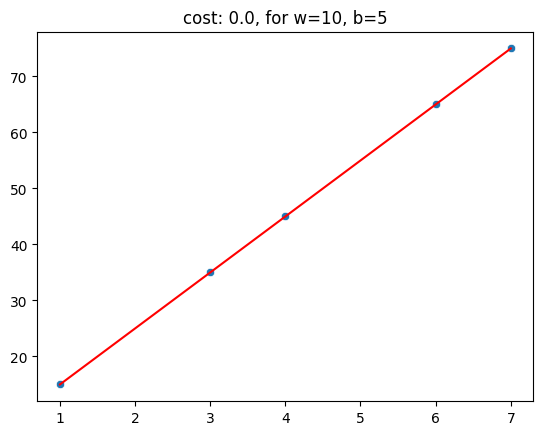

In [12]:
w=10
b=5

prediction = make_pred(X,y,w=w,b=b)
print(prediction)

sns.scatterplot(x=X, y=y)
plt.plot(X, prediction, color='red')
plt.title(f"cost: {compute_cost(X,y,w=w,b=b)}, for w={w}, b={b}")

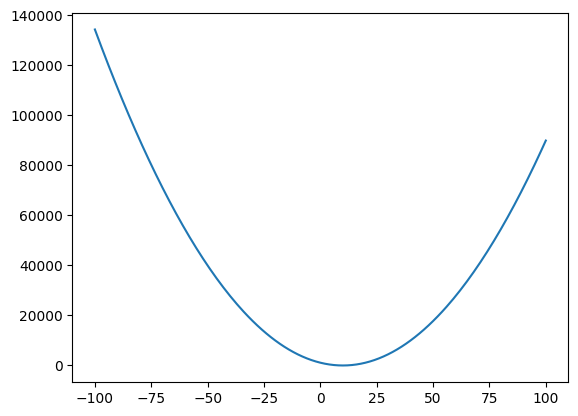

In [13]:
w=[]
cost=[]

for i in range(-100, 101):
    cost_i = compute_cost(X,y,w=i,b=5)
    w.append(i)
    cost.append(cost_i)

plt.plot(w,cost)

In [14]:
def calculate_gradient(X,y,w,b):
    m=X.shape[0] # no of data points

    dj_dw = 0.0
    dj_db = 0.0

    for i in range(m):
        prediction = w * X[i] + b
        error = prediction - y[i]

        dj_dw = dj_dw + (error * X[i])
        dj_db = dj_db + error

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db


In [15]:
calculate_gradient(X,y,w=10,b=5)

(np.float64(0.0), np.float64(0.0))

In [16]:
def gradient_descent(X,y,w_input, b_input, max_iters, alpha=0.01):

    w = w_input
    b = b_input

    cost_memo = []

    for i in range(max_iters):
        dj_dw, dj_db = calculate_gradient(X,y,w,b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost_memo.append(compute_cost(X,y,w,b))

        if i%100 == 0:
            print(f"iteration: {i}, cost: {cost_memo[i]}, w: {w}, b: {b}")

    return w, b, cost_memo

In [17]:
gradient_descent(X,y,w_input=0, b_input=0, max_iters=1000, alpha=0.01)

iteration: 0, cost: 790.37166, w: 2.43, b: 0.47000000000000003
iteration: 100, cost: 0.6120066399205837, w: 10.46591953814626, b: 2.5592744809869727
iteration: 200, cost: 0.41152019687322394, w: 10.382057239261956, b: 2.9985882171300546
iteration: 300, cost: 0.2767108416610512, w: 10.313289574937954, b: 3.358828514956577
iteration: 400, cost: 0.1860635042327127, w: 10.256899615236728, b: 3.6542280472350646
iteration: 500, cost: 0.12511120778477827, w: 10.210659458814899, b: 3.896457703930417
iteration: 600, cost: 0.0841261932473795, w: 10.172742211183513, b: 4.095087695420831
iteration: 700, cost: 0.05656740523574873, w: 10.141649806243873, b: 4.257965660314708
iteration: 800, cost: 0.038036564018722505, w: 10.116153819448396, b: 4.391526716471991
iteration: 900, cost: 0.025576216485816435, w: 10.095246934183749, b: 4.501047704983054


(np.float64(10.078258287598194),
 np.float64(4.5900429495621635),
 [np.float64(790.37166),
  np.float64(468.9569536391999),
  np.float64(278.39740382959656),
  np.float64(165.4183470237311),
  np.float64(98.43467440493934),
  np.float64(58.72042820979756),
  np.float64(35.17349394244639),
  np.float64(21.211727821128783),
  np.float64(12.932754592847028),
  np.float64(8.022961371024904),
  np.float64(5.1106695555603725),
  np.float64(3.3826479383869787),
  np.float64(2.3567536837198864),
  np.float64(1.7471373073828727),
  np.float64(1.3843263505598626),
  np.float64(1.1678451489139516),
  np.float64(1.0381243736821046),
  np.float64(0.9598469574580879),
  np.float64(0.9120743435012206),
  np.float64(0.8823926056921673),
  np.float64(0.863441841197818),
  np.float64(0.8508585411410318),
  np.float64(0.8420556777575289),
  np.float64(0.8354994510270339),
  np.float64(0.8302804912893264),
  np.float64(0.8258596368590307),
  np.float64(0.8219172124409301),
  np.float64(0.818263670373842),

In [21]:
print(w, b)

predictions = make_pred(X,y,w=w,b=b)
print(predictions)

sns.scatterplot(x=X, y=y)
plt.plot(X, prediction, color='red')

[-100, -99, -98, -97, -96, -95, -94, -93, -92, -91, -90, -89, -88, -87, -86, -85, -84, -83, -82, -81, -80, -79, -78, -77, -76, -75, -74, -73, -72, -71, -70, -69, -68, -67, -66, -65, -64, -63, -62, -61, -60, -59, -58, -57, -56, -55, -54, -53, -52, -51, -50, -49, -48, -47, -46, -45, -44, -43, -42, -41, -40, -39, -38, -37, -36, -35, -34, -33, -32, -31, -30, -29, -28, -27, -26, -25, -24, -23, -22, -21, -20, -19, -18, -17, -16, -15, -14, -13, -12, -11, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100] 5


TypeError: can only concatenate list (not "int") to list